In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# Path to your dataset
DATA_PATH = "/Users/rugved/Desktop/brain_tumor_dataset"  # change if your folder name is different

IMG_SIZE = 128
X, y = [], []

for label, folder in enumerate(["no", "yes"]):  # no=0, yes=1
    path = os.path.join(DATA_PATH, folder)
    for img_name in os.listdir(path):
        img = cv2.imread(os.path.join(path, img_name))
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            y.append(label)

X = np.array(X) / 255.0  # normalize
y = np.array(y)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (202, 128, 128, 3)
Test size: (51, 128, 128, 3)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary output: tumor or not
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/opt/anaconda3/envs/brain_tumor/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

print("Training Complete!")

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6522 - loss: 0.6418 - val_accuracy: 0.7561 - val_loss: 0.5166
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7702 - loss: 0.5154 - val_accuracy: 0.7561 - val_loss: 0.5835
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7888 - loss: 0.5324 - val_accuracy: 0.6098 - val_loss: 0.8152
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7329 - loss: 0.5500 - val_accuracy: 0.7805 - val_loss: 0.4983
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8261 - loss: 0.4735 - val_accuracy: 0.7805 - val_loss: 0.5013
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7764 - loss: 0.4450 - val_accuracy: 0.7805 - val_loss: 0.5549
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7578 - loss: 0.4540 - val_accuracy: 0.8293 - val_loss: 0.4915
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8075 - loss: 0.4232 - val_accuracy: 0.8293 - val_loss: 0.4863


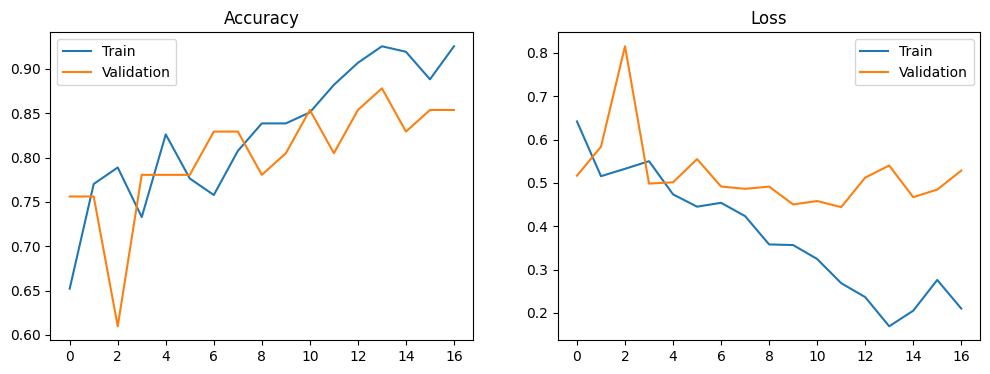

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


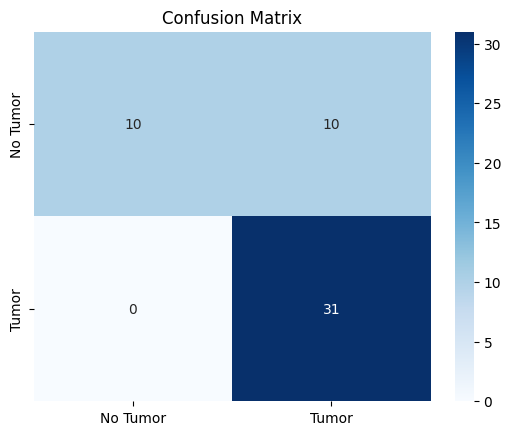

              precision    recall  f1-score   support

    No Tumor       1.00      0.50      0.67        20
       Tumor       0.76      1.00      0.86        31

    accuracy                           0.80        51
   macro avg       0.88      0.75      0.76        51
weighted avg       0.85      0.80      0.78        51



In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Accuracy & Loss Curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

# 2. Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor','Tumor'],
            yticklabels=['No Tumor','Tumor'])
plt.title('Confusion Matrix')
plt.show()

# 3. Classification Report
print(classification_report(y_test, y_pred, target_names=['No Tumor','Tumor']))

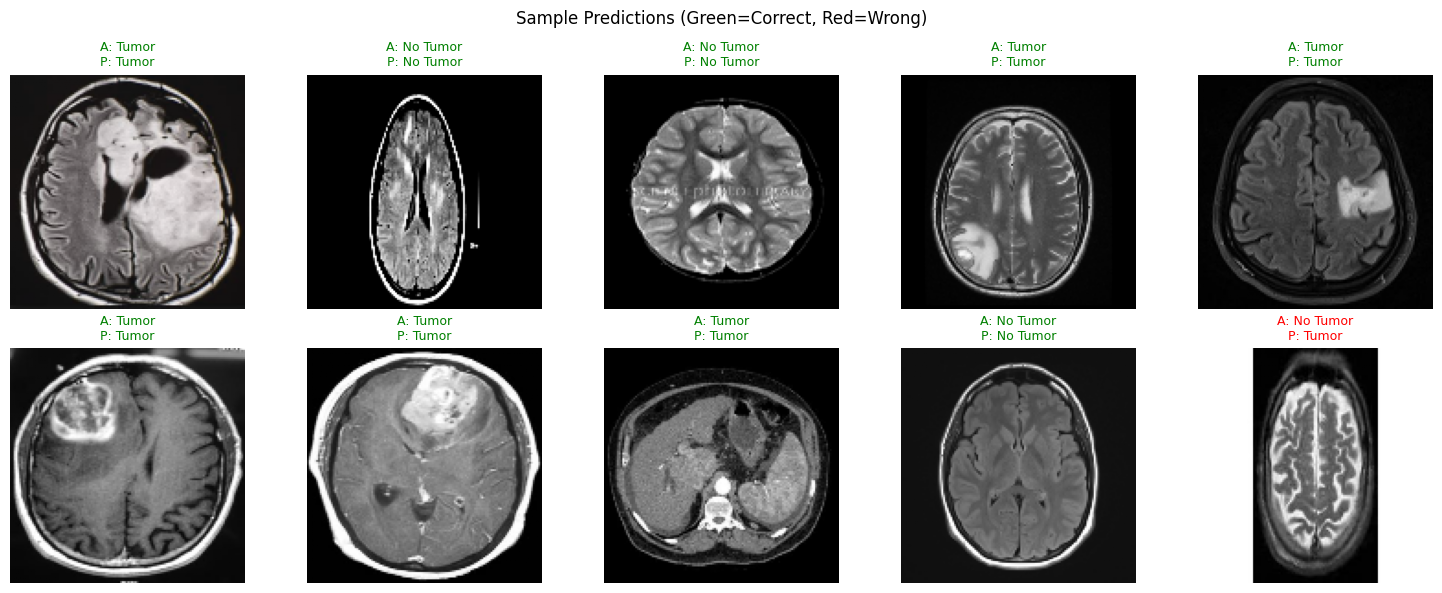

In [10]:
# Show sample test predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(X_test[i])
    actual = "Tumor" if y_test[i] == 1 else "No Tumor"
    predicted = "Tumor" if y_pred[i] == 1 else "No Tumor"
    color = "green" if actual == predicted else "red"
    axes[i].set_title(f"A: {actual}\nP: {predicted}", color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()


In [11]:
model.save("brain_tumor_model.h5")
print("Model saved!")

Model saved!
